# **ANLC 801 - Capstone**
# **Predicting Customer Churn Using Machine Learning Techniques**
# **Final Project Code**

**1. Data Loading**

In [43]:
import pandas as pd

from google.colab import drive
drive.mount ('/content/drive', force_remount=True)
df = pd.read_csv('/content/drive/My Drive/Telco Customer Churn.csv')

df.head(3)

Mounted at /content/drive


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


**2. Libraries and Environment Setup**

In [44]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

**3. Data Cleaning and Preparation**

In [45]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop customer ID (not useful for modeling)
df.drop("customerID", axis=1, inplace=True)

# Drop rows with missing TotalCharges
df.dropna(inplace=True)

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

**4. Exploratory Data Analysis (EDA)**

In [46]:
categorical_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod"
]

for col in categorical_cols:
    churn_table = pd.crosstab(df[col], df["Churn"], normalize="index") * 100
    print(f"\nChurn Rate by {col}")
    print(churn_table)



Churn Rate by gender
Churn          No        Yes
gender                      
Female  73.040482  26.959518
Male    73.795435  26.204565

Churn Rate by SeniorCitizen
Churn                 No        Yes
SeniorCitizen                      
0              76.349745  23.650255
1              58.318739  41.681261

Churn Rate by Partner
Churn           No        Yes
Partner                      
No       67.023908  32.976092
Yes      80.282935  19.717065

Churn Rate by Dependents
Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.468795  15.531205

Churn Rate by PhoneService
Churn                No        Yes
PhoneService                      
No            75.000000  25.000000
Yes           73.252519  26.747481

Churn Rate by MultipleLines
Churn                    No        Yes
MultipleLines                         
No                74.918759  25.081241
No phone service  75.000000  25.000000
Yes               71.351534  28.648

**4.1 Churn Distribution**

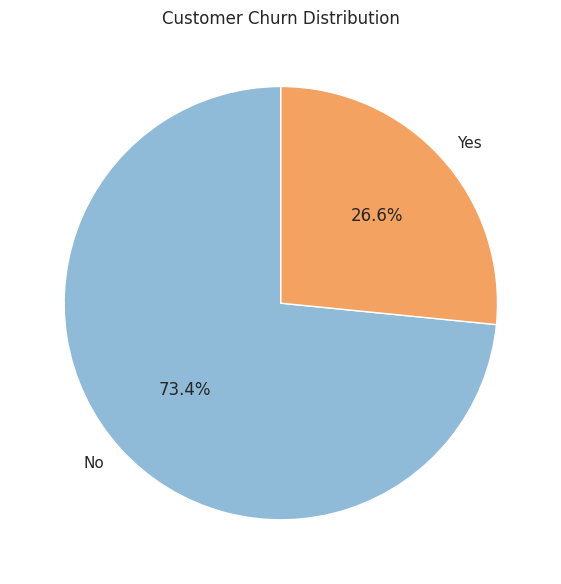

In [47]:
import matplotlib.pyplot as plt

# Churn counts
churn_counts = df["Churn"].value_counts()

# Labels and colors
labels = ["No", "Yes"]
colors = ["#8FBBD9", "#F4A261"]  # soft blue & light orange (academic-friendly)

plt.figure(figsize=(6,6))
plt.pie(
    churn_counts,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white"}
)

plt.title("Customer Churn Distribution")
plt.tight_layout()
plt.show()


/tmp/ipython-input-2859891494.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette={"No": "#8fbcd4", "Yes": "#f4a261"})


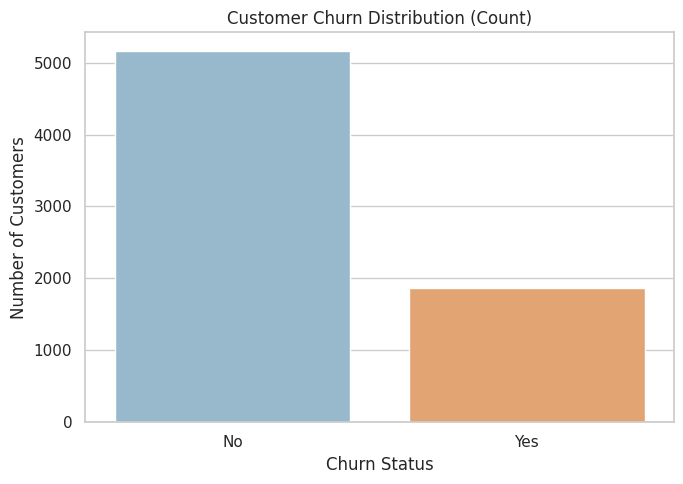

In [48]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Churn", palette={"No": "#8fbcd4", "Yes": "#f4a261"})
plt.title("Customer Churn Distribution (Count)")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


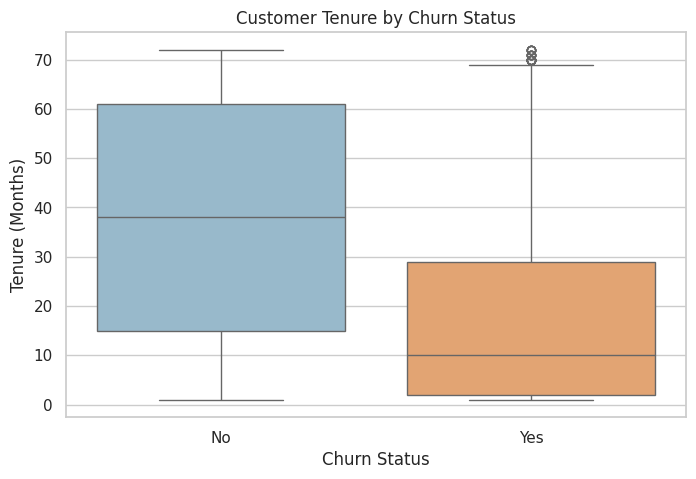

In [51]:
sns.boxplot(data=df, x="Churn", y="tenure", hue="Churn", palette={"No": "#8fbcd4", "Yes": "#f4a261"})
plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")
plt.show()

**4.2 Churn Rates by Key Categorical Variables**

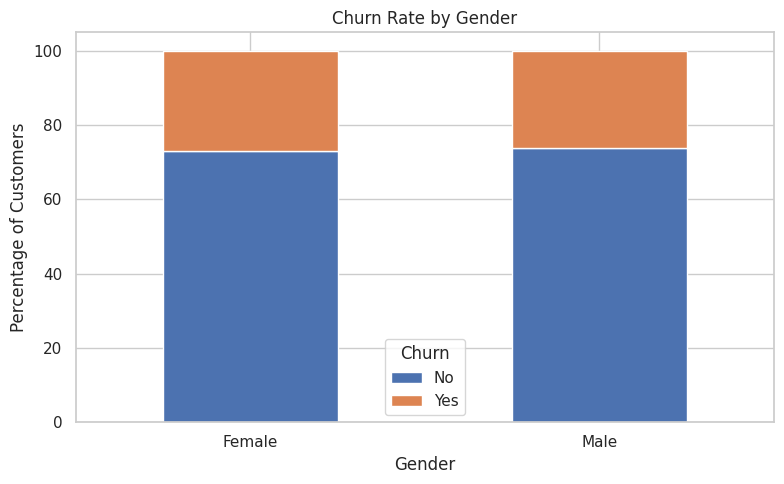

In [7]:
gender_churn = pd.crosstab(df["gender"], df["Churn"], normalize="index") * 100

gender_churn.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Gender")
plt.ylabel("Percentage of Customers")
plt.xlabel("Gender")
plt.legend(title="Churn", labels=["No", "Yes"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


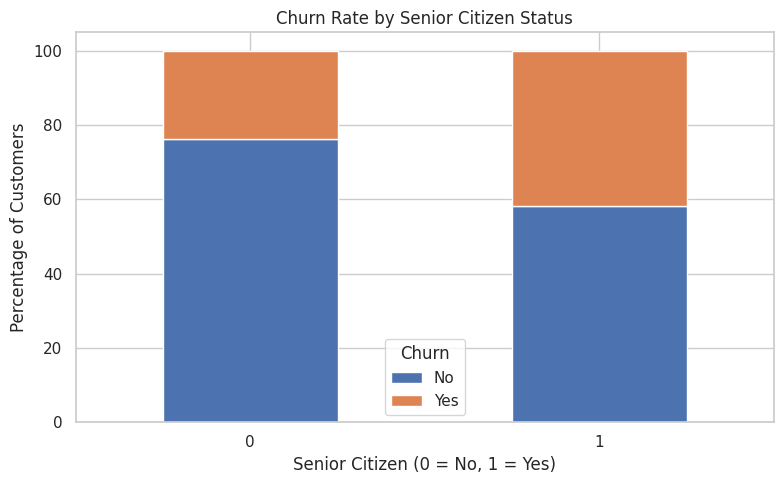

In [8]:
senior_churn = pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100

senior_churn.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Senior Citizen Status")
plt.ylabel("Percentage of Customers")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.legend(title="Churn", labels=["No", "Yes"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


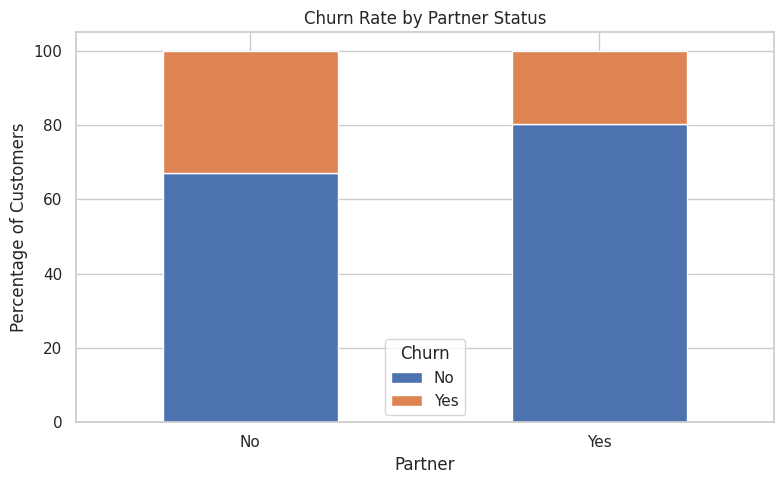

In [9]:
partner_churn = pd.crosstab(df["Partner"], df["Churn"], normalize="index") * 100

partner_churn.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Partner Status")
plt.ylabel("Percentage of Customers")
plt.xlabel("Partner")
plt.legend(title="Churn", labels=["No", "Yes"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


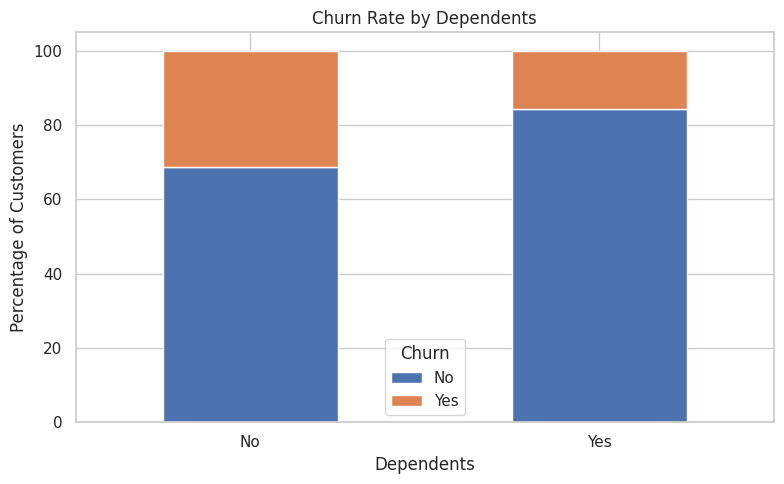

In [10]:
dependents_churn = pd.crosstab(df["Dependents"], df["Churn"], normalize="index") * 100

dependents_churn.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Dependents")
plt.ylabel("Percentage of Customers")
plt.xlabel("Dependents")
plt.legend(title="Churn", labels=["No", "Yes"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


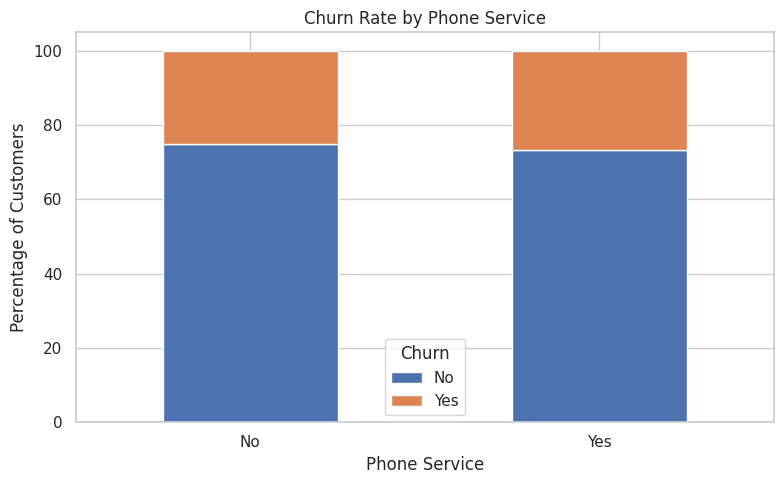

In [11]:
phoneservice_churn = pd.crosstab(df["PhoneService"], df["Churn"], normalize="index") * 100

phoneservice_churn.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Phone Service")
plt.ylabel("Percentage of Customers")
plt.xlabel("Phone Service")
plt.legend(title="Churn", labels=["No", "Yes"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


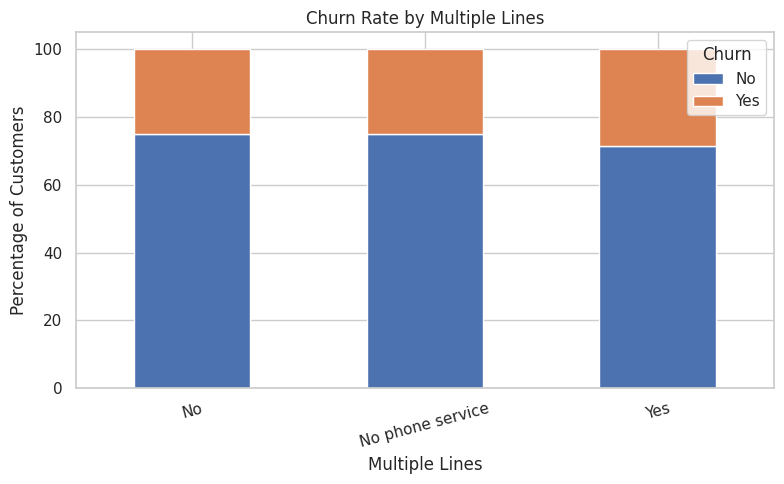

In [12]:
multilines_churn = pd.crosstab(df["MultipleLines"], df["Churn"], normalize="index") * 100

multilines_churn.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Multiple Lines")
plt.ylabel("Percentage of Customers")
plt.xlabel("Multiple Lines")
plt.legend(title="Churn", labels=["No", "Yes"])
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


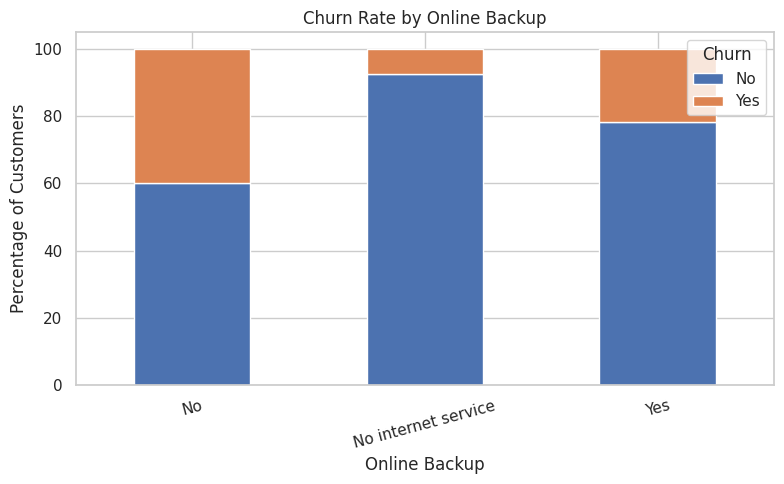

In [13]:
backup_churn = pd.crosstab(df["OnlineBackup"], df["Churn"], normalize="index") * 100

backup_churn.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Online Backup")
plt.ylabel("Percentage of Customers")
plt.xlabel("Online Backup")
plt.legend(title="Churn", labels=["No", "Yes"])
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


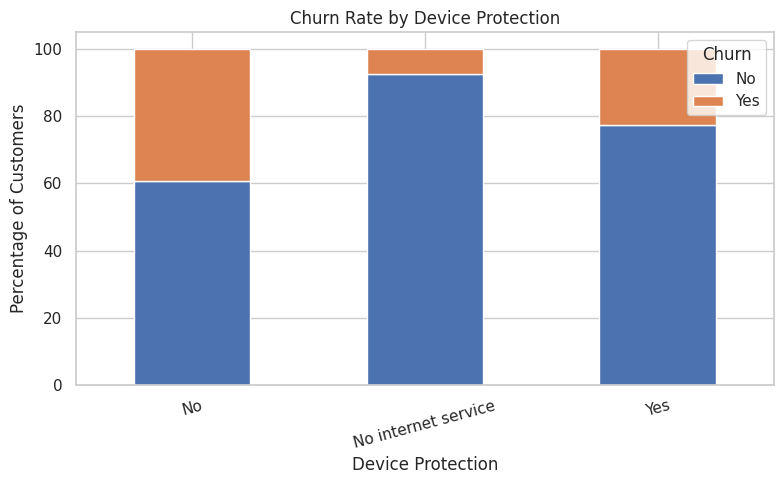

In [14]:
device_churn = pd.crosstab(df["DeviceProtection"], df["Churn"], normalize="index") * 100

device_churn.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Device Protection")
plt.ylabel("Percentage of Customers")
plt.xlabel("Device Protection")
plt.legend(title="Churn", labels=["No", "Yes"])
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


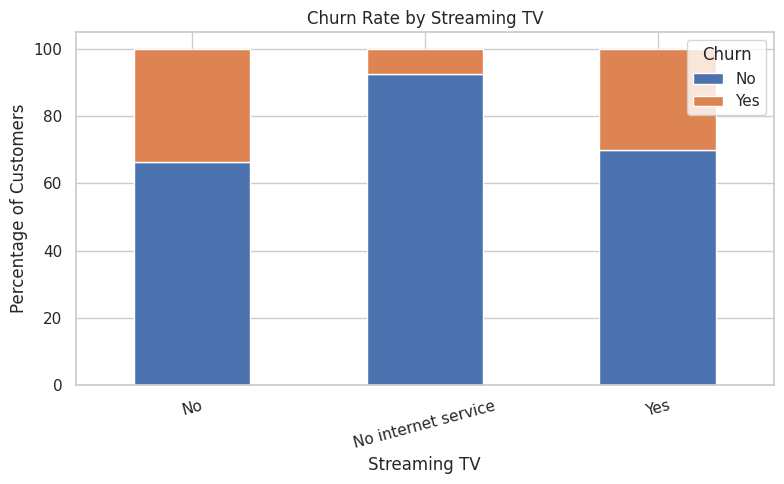

In [15]:
tv_churn = pd.crosstab(df["StreamingTV"], df["Churn"], normalize="index") * 100

tv_churn.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Streaming TV")
plt.ylabel("Percentage of Customers")
plt.xlabel("Streaming TV")
plt.legend(title="Churn", labels=["No", "Yes"])
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


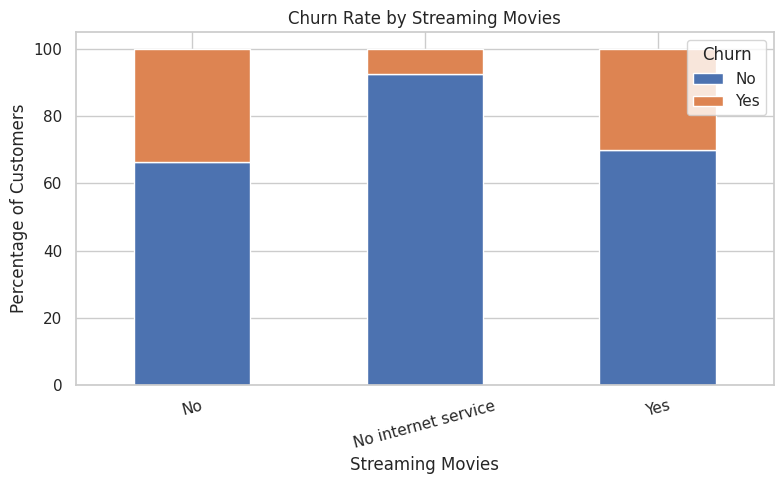

In [16]:
movies_churn = pd.crosstab(df["StreamingMovies"], df["Churn"], normalize="index") * 100

movies_churn.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Streaming Movies")
plt.ylabel("Percentage of Customers")
plt.xlabel("Streaming Movies")
plt.legend(title="Churn", labels=["No", "Yes"])
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


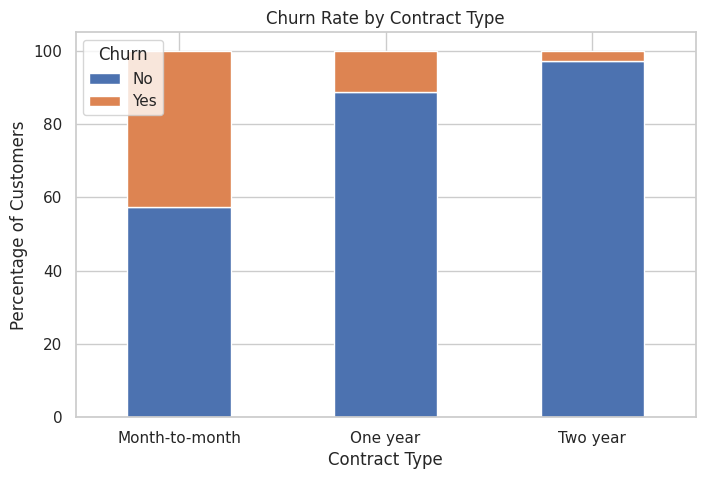

In [17]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

contract_churn.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Percentage of Customers")
plt.xlabel("Contract Type")
plt.legend(title="Churn", labels=["No", "Yes"])
plt.xticks(rotation=0)
plt.show()


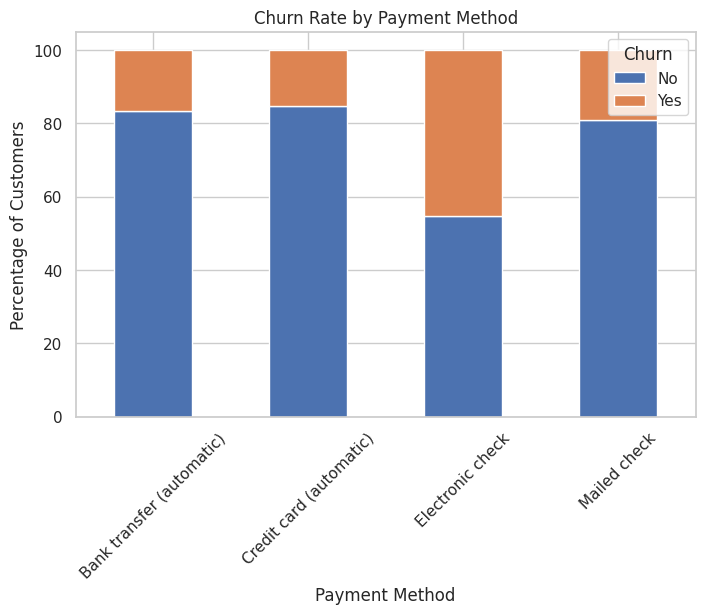

In [18]:
payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

payment_churn.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Payment Method")
plt.ylabel("Percentage of Customers")
plt.xlabel("Payment Method")
plt.legend(title="Churn", labels=["No", "Yes"])
plt.xticks(rotation=45)
plt.show()


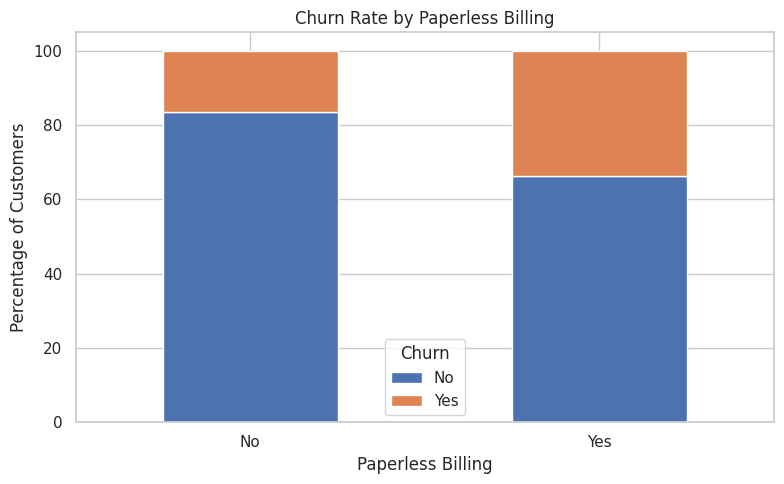

In [19]:
paperless_churn = pd.crosstab(df["PaperlessBilling"], df["Churn"], normalize="index") * 100

paperless_churn.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Paperless Billing")
plt.ylabel("Percentage of Customers")
plt.xlabel("Paperless Billing")
plt.legend(title="Churn", labels=["No", "Yes"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


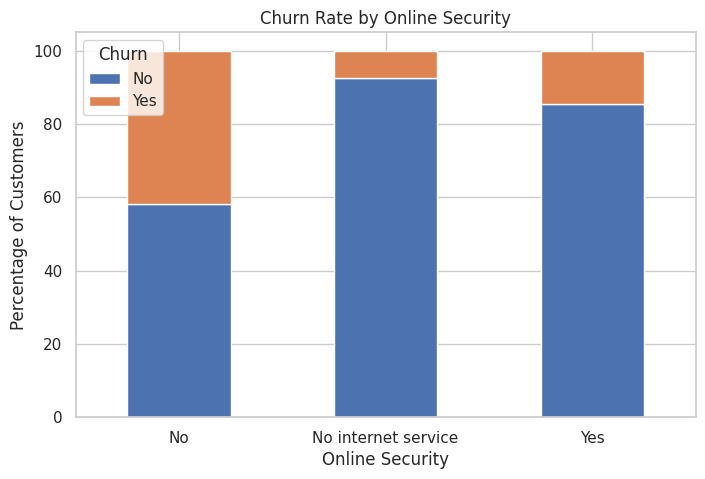

In [20]:
security_churn = pd.crosstab(df["OnlineSecurity"], df["Churn"], normalize="index") * 100

security_churn.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Online Security")
plt.ylabel("Percentage of Customers")
plt.xlabel("Online Security")
plt.legend(title="Churn", labels=["No", "Yes"])
plt.xticks(rotation=0)
plt.show()


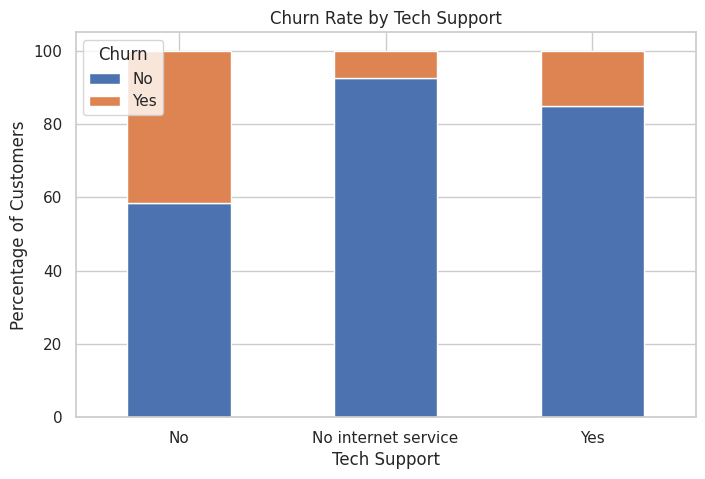

In [21]:
tech_churn = pd.crosstab(df["TechSupport"], df["Churn"], normalize="index") * 100

tech_churn.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Tech Support")
plt.ylabel("Percentage of Customers")
plt.xlabel("Tech Support")
plt.legend(title="Churn", labels=["No", "Yes"])
plt.xticks(rotation=0)
plt.show()


**4.3 Exploratory Analysis of Numerical Variables**

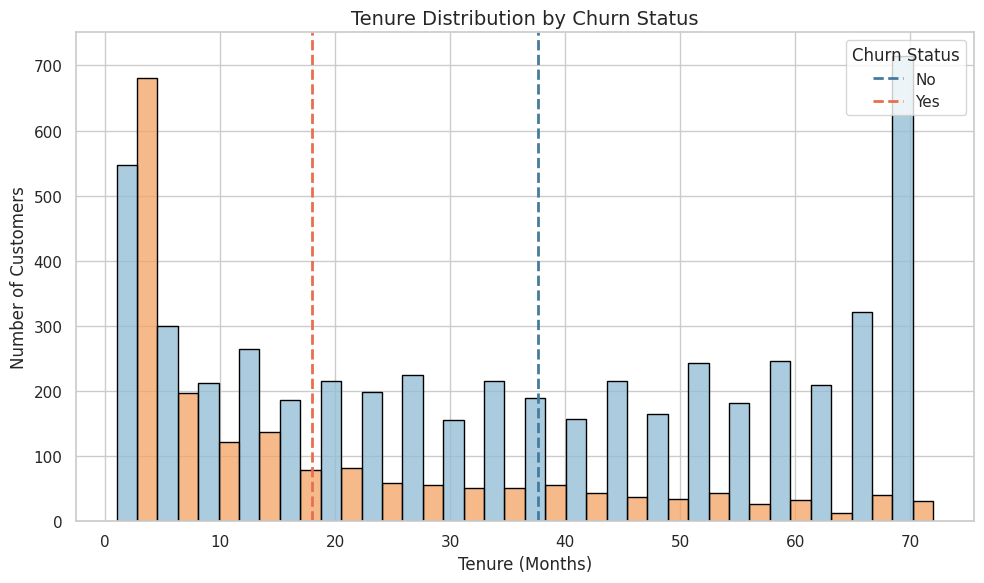

In [22]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=20,
    multiple="dodge",
    palette={"No": "#8fbcd4", "Yes": "#f4a261"},
    edgecolor="black"
)

plt.title("Tenure Distribution by Churn Status", fontsize=14)
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.axvline(df[df["Churn"] == "No"]["tenure"].mean(), color="#457b9d", linestyle="--", linewidth=2)
plt.axvline(df[df["Churn"] == "Yes"]["tenure"].mean(), color="#e76f51", linestyle="--", linewidth=2)

plt.legend(title="Churn Status", labels=["No", "Yes"])
plt.tight_layout()
plt.show()


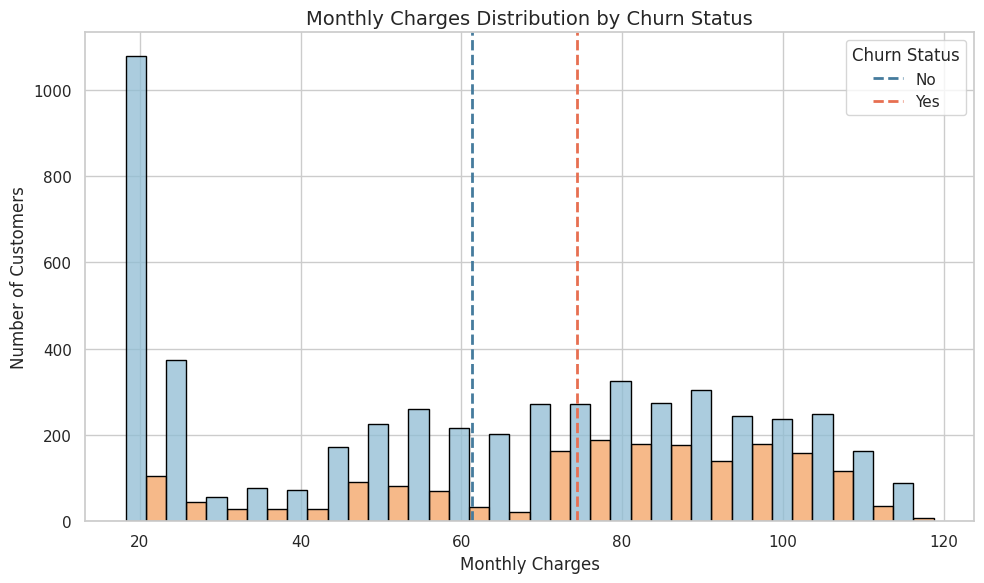

In [23]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    bins=20,
    multiple="dodge",
    palette={"No": "#8fbcd4", "Yes": "#f4a261"},
    edgecolor="black"
)

plt.title("Monthly Charges Distribution by Churn Status", fontsize=14)
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

# Mean lines (no labels so legend stays clean)
plt.axvline(df[df["Churn"] == "No"]["MonthlyCharges"].mean(), color="#457b9d", linestyle="--", linewidth=2)
plt.axvline(df[df["Churn"] == "Yes"]["MonthlyCharges"].mean(), color="#e76f51", linestyle="--", linewidth=2)

plt.legend(title="Churn Status", labels=["No", "Yes"])
plt.tight_layout()
plt.show()


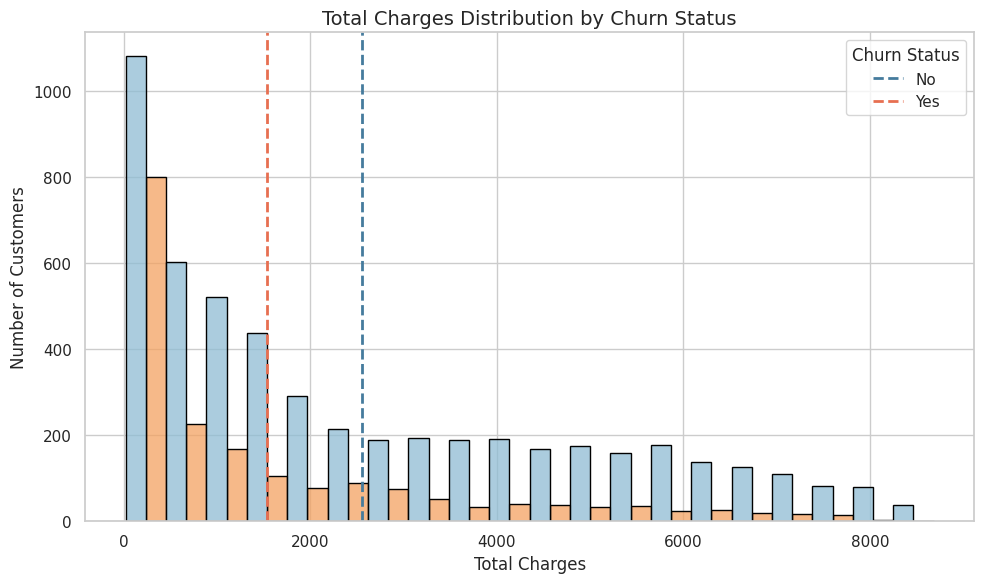

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="TotalCharges",
    hue="Churn",
    bins=20,
    multiple="dodge",
    palette={"No": "#8fbcd4", "Yes": "#f4a261"},
    edgecolor="black"
)

plt.title("Total Charges Distribution by Churn Status", fontsize=14)
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

# Mean lines (no labels so legend stays clean)
plt.axvline(df[df["Churn"] == "No"]["TotalCharges"].mean(), color="#457b9d", linestyle="--", linewidth=2)
plt.axvline(df[df["Churn"] == "Yes"]["TotalCharges"].mean(), color="#e76f51", linestyle="--", linewidth=2)

plt.legend(title="Churn Status", labels=["No", "Yes"])
plt.tight_layout()
plt.show()


**5. Statistical Association Testing (Chi-Square)**

In [52]:
from scipy.stats import chi2_contingency
import pandas as pd

categorical_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod"
]

chi_square_results = []

for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df["Churn"])
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    chi_square_results.append({
        "Variable": col,
        "Chi-square Statistic": chi2,
        "p-value": p
    })

chi_results_df = pd.DataFrame(chi_square_results)
chi_results_df = chi_results_df.sort_values(by="p-value")

chi_results_df


,Variable,Chi-square Statistic,p-value
12,Contract,1179.545829,7.326182e-257
6,OnlineSecurity,846.677389,1.400687e-184
9,TechSupport,824.925564,7.407808e-180
14,PaymentMethod,645.429900,1.426310e-139
7,OnlineBackup,599.175185,7.776099e-131
8,DeviceProtection,555.880327,1.959389e-121
11,StreamingMovies,374.268432,5.353560e-82
10,StreamingTV,372.456502,1.324641e-81
13,PaperlessBilling,256.874908,8.236203e-58
3,Dependents,186.321639,2.019659e-42


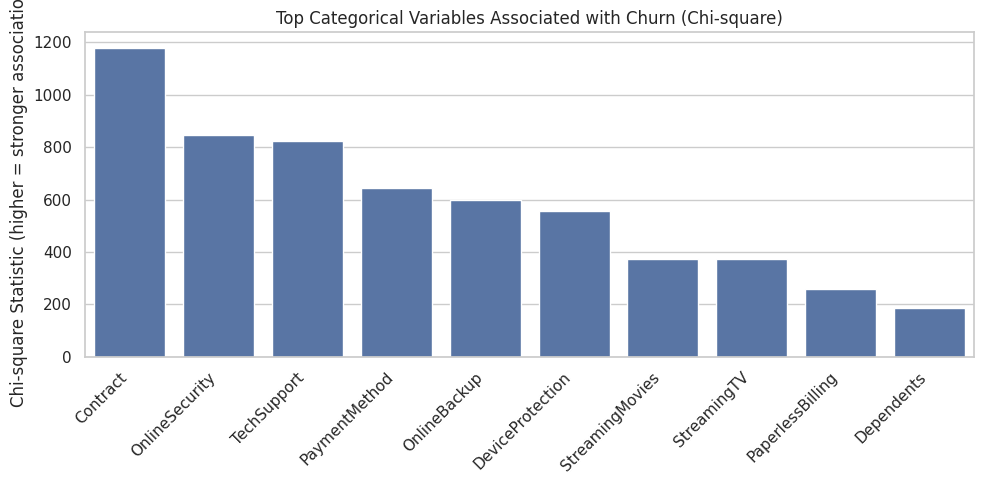

In [54]:
# Plot top 10 most significant chi-square associations (by chi-square statistic)
top10 = chi_results_df.sort_values("Chi-square Statistic", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=top10, x="Variable", y="Chi-square Statistic")
plt.title("Top Categorical Variables Associated with Churn (Chi-square)")
plt.xlabel("")
plt.ylabel("Chi-square Statistic (higher = stronger association)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**6. Predictive Modeling: Logistic Regression**

In [26]:
# Convert target variable to binary
df["Churn"] = df["Churn"].str.strip().map({"Yes": 1, "No": 0})

# Drop rows where Churn is missing after mapping
df = df.dropna(subset=["Churn"])

# Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]


# One-hot encode categorical variables in X
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

In [28]:
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:,1]


**7. Model Evaluation**

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)


Accuracy: 0.8071090047393364
Precision: 0.6590909090909091
Recall: 0.5686274509803921
F1 Score: 0.6105263157894737
ROC-AUC: 0.8377534122986597


In [30]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1549
           1       0.66      0.57      0.61       561

    accuracy                           0.81      2110
   macro avg       0.76      0.73      0.74      2110
weighted avg       0.80      0.81      0.80      2110



In [31]:
from sklearn.metrics import classification_report
import pandas as pd

report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

# Optional: cleaner formatting
report_df = report_df.rename_axis("Class").reset_index()
report_df[["precision","recall","f1-score","support"]] = report_df[["precision","recall","f1-score","support"]].round(3)

report_df


,Class,precision,recall,f1-score,support
0,0,0.851,0.893,0.872,1549.000
1,1,0.659,0.569,0.611,561.000
2,accuracy,0.807,0.807,0.807,0.807
3,macro avg,0.755,0.731,0.741,2110.000
4,weighted avg,0.800,0.807,0.802,2110.000


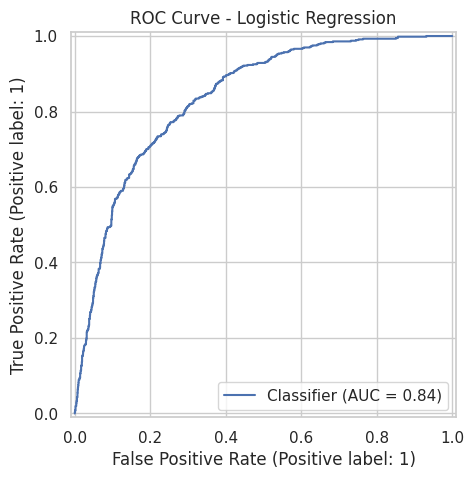

In [32]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve - Logistic Regression")
plt.show()


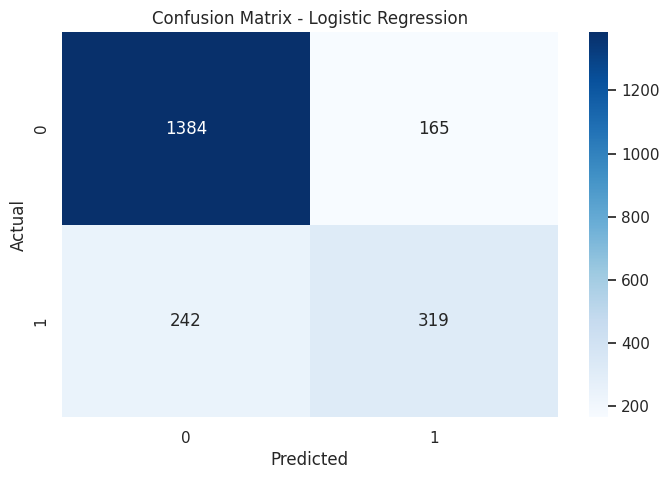

In [33]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**8. Feature Importance Analysis**

In [34]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

coefficients["Abs_Coefficient"] = np.abs(coefficients["Coefficient"])
coefficients = coefficients.sort_values(by="Abs_Coefficient", ascending=False)

coefficients.head(10)


,Feature,Coefficient,Abs_Coefficient
1,tenure,-1.453474,1.453474
2,MonthlyCharges,-0.761563,0.761563
3,TotalCharges,0.740914,0.740914
10,InternetService_Fiber optic,0.672710,0.672710
25,Contract_Two year,-0.567817,0.567817
24,Contract_One year,-0.280008,0.280008
21,StreamingTV_Yes,0.225577,0.225577
9,MultipleLines_Yes,0.220639,0.220639
23,StreamingMovies_Yes,0.219688,0.219688
28,PaymentMethod_Electronic check,0.168436,0.168436


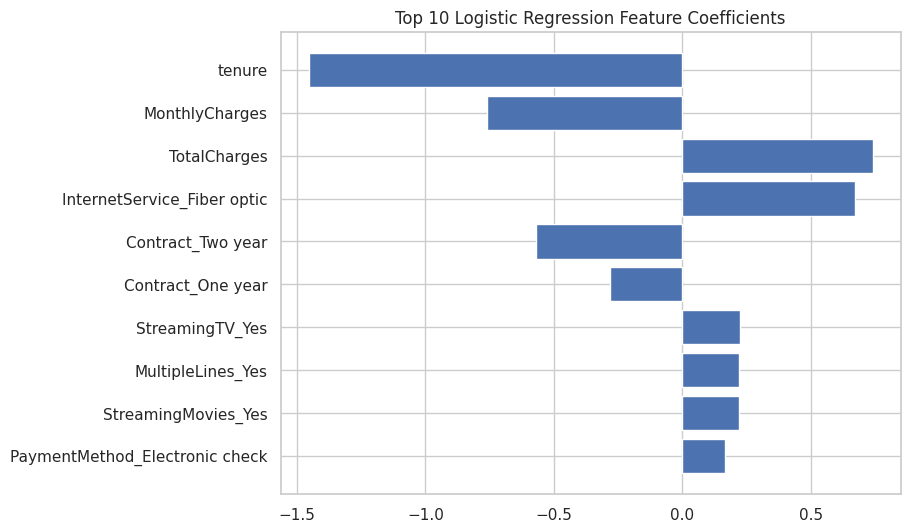

In [35]:
top_features = coefficients.head(10)

plt.figure(figsize=(8,6))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.gca().invert_yaxis()
plt.title("Top 10 Logistic Regression Feature Coefficients")
plt.show()


**9. Customer Segmentation (Clustering)**

In [36]:
cluster_data = df[["tenure", "MonthlyCharges"]]
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)


In [37]:
from sklearn.cluster import KMeans

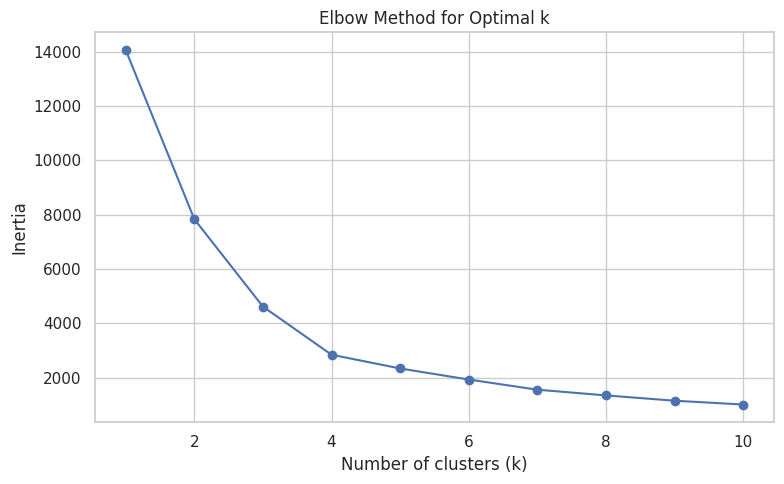

In [38]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(cluster_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(list(k_range), inertia, marker="o")
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()


In [39]:
# K-Means clustering (k = 3) on standardized tenure and MonthlyCharges
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(cluster_scaled)

# Assign cluster labels back to the dataframe
df["Cluster"] = clusters


In [40]:
cluster_summary = df.groupby("Cluster")[["tenure", "MonthlyCharges"]].mean()
cluster_counts = df["Cluster"].value_counts()
cluster_churn = df.groupby("Cluster")["Churn"].mean()

print("Cluster Summary:")
print(cluster_summary)

print("\nCluster Counts:")
print(cluster_counts)

print("\nChurn Rate by Cluster:")
print(cluster_churn)


Cluster Summary:
            tenure  MonthlyCharges
Cluster                           
0        12.596861       75.021076
1        29.388032       26.514727
2        57.968435       88.992087

Cluster Counts:
Cluster
0    2612
2    2281
1    2139
Name: count, dtype: int64

Churn Rate by Cluster:
Cluster
0    0.477029
1    0.124357
2    0.156510
Name: Churn, dtype: float64


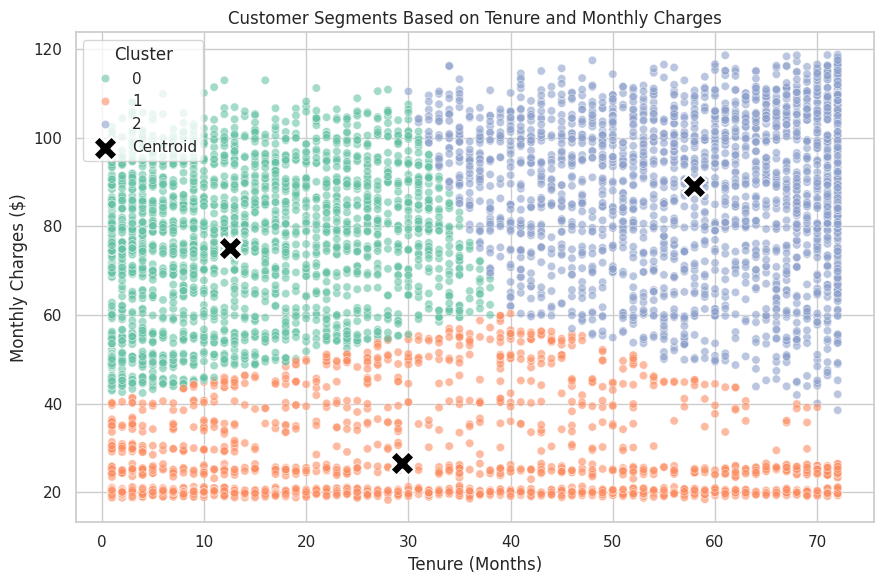

In [41]:
# Centroids in original units (because clustering used scaled data)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Cluster",
    palette="Set2",
    alpha=0.6
)

plt.scatter(
    centroids[:, 0], centroids[:, 1],
    marker="X", s=300, c="black", edgecolors="white", linewidths=1.5,
    label="Centroid"
)

plt.title("Customer Segments Based on Tenure and Monthly Charges")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges ($)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


- Month-to-month contracts and electronic check payments are strongly associated with higher churn.
- Tenure is the most influential predictor, with shorter-tenure customers significantly more likely to churn.
- Customers lacking online security and technical support exhibit elevated churn risk.
- Cluster analysis identifies a high-risk segment characterized by low tenure and high monthly charges.
